In [8]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

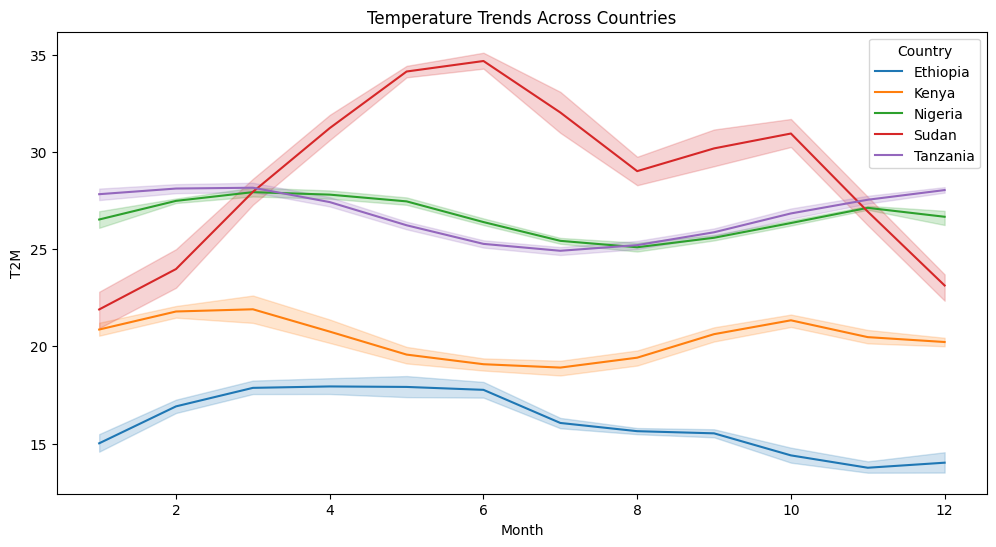

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_temp = df.groupby(["Country", "YEAR", "Month"])["T2M"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_temp, x="Month", y="T2M", hue="Country")
plt.title("Temperature Trends Across Countries")
plt.show()

Sudan consistently exhibits the highest temperatures across all months, peaking around mid-year, indicating significant exposure to extreme heat conditions. In contrast, Ethiopia remains the coolest country, though it follows a similar seasonal pattern. All countries show a mid-year temperature peak and a decline toward the end of the year, reflecting consistent seasonal climate cycles across the region.

In [10]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Sudan experiences the highest average temperature (29.16°C) and also the highest variability (std = 4.68), making it the most climate-stressed country in the dataset. In contrast, Nigeria shows high but stable temperatures, indicating consistent heat exposure but lower variability risk. Ethiopia remains the coolest country, though it is not immune to variability-driven climate shifts.

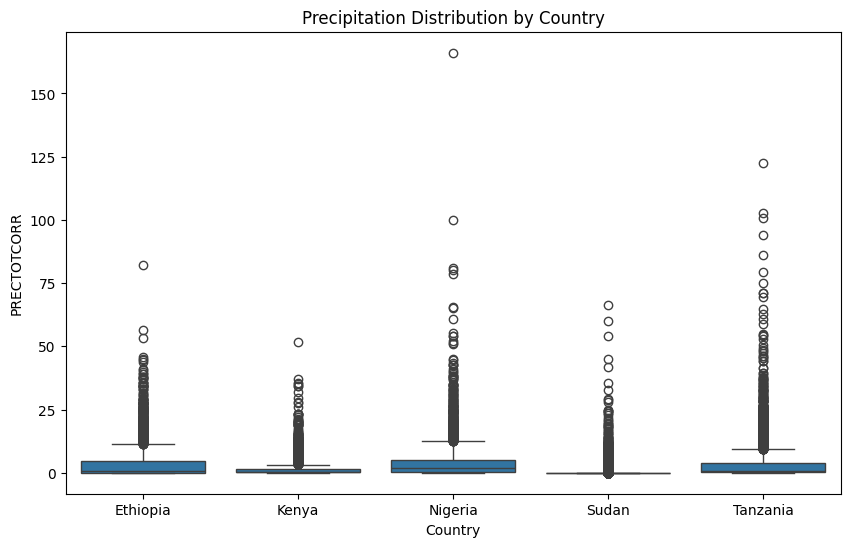

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

In [12]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


Tanzania exhibits the highest rainfall variability (std = 8.00), indicating extreme unpredictability in precipitation patterns, which increases both flood and drought risks. Nigeria also shows high variability (7.27), suggesting unstable hydrological conditions across West Africa.

Ethiopia shows moderate variability (6.29), signaling emerging climate instability that may increasingly affect agricultural productivity.

Kenya demonstrates relatively stable rainfall patterns compared to its neighbors, while Sudan’s low median rainfall (0.00) combined with variability suggests prolonged dry conditions with rare but extreme rainfall events.

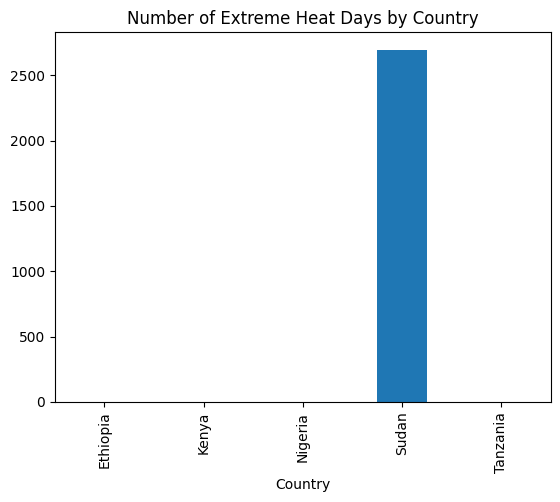

In [17]:
extreme_heat = df[df["T2M_MAX"] > 35].groupby("Country").size().reindex(df["Country"].unique(), fill_value=0)
extreme_heat.plot(kind="bar", title="Number of Extreme Heat Days by Country")
plt.show()

sudan is the only country who experienced extreme heat days

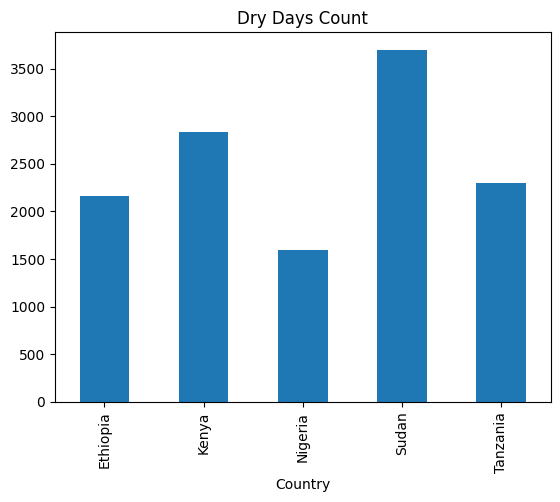

In [18]:
df["dry"] = df["PRECTOTCORR"] < 1

dry_days = df.groupby("Country")["dry"].sum()

dry_days.plot(kind="bar", title="Dry Days Count")
plt.show()

Sudan has by far the highest number of dry days, indicating persistent water scarcity conditions. Kenya and Tanzania also record high dry-day counts, suggesting notable seasonal dryness. Ethiopia is moderate, while Nigeria has the lowest dry-day total among the five countries, implying relatively fewer prolonged dry conditions.
Overall, the pattern highlights stronger drought exposure risk in Sudan and, to a lesser extent, Kenya and Tanzania.

In [19]:
from scipy.stats import f_oneway

groups = [group["T2M"].dropna() for name, group in df.groupby("Country")]

stat, p = f_oneway(*groups)

print("p-value:", p)

p-value: 0.0


In [20]:
ranking = pd.DataFrame({
    "Country": temp_summary.index,
    "Temp Mean": temp_summary["mean"],
    "Rain Variability": rain_summary["std"],
    "Extreme Heat": extreme_heat,
    "Dry Days": dry_days
})

ranking.sort_values(by=["Extreme Heat", "Dry Days"], ascending=False)

,Country,Temp Mean,Rain Variability,Extreme Heat,Dry Days
Country,,,,,
Sudan,Sudan,28.759007,3.057672,2694,3696
Kenya,Kenya,20.427600,3.180228,0,2831
Tanzania,Tanzania,26.802422,8.003947,0,2303
Ethiopia,Ethiopia,16.068500,6.289061,0,2161
Nigeria,Nigeria,26.656928,7.266742,0,1595


The analysis reveals a clear climate vulnerability gradient across Africa, with Sudan representing an extreme hotspot of heat and drought stress, while Tanzania and Nigeria face increasing hydrological instability. Ethiopia remains comparatively stable but is transitioning toward higher variability.